In [1]:
%load_ext autoreload
%autoreload 2

import os, h5py, math
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from tqdm import tqdm

from msfm.utils import files, catalog, observation

In [2]:
conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v16/default.yaml"
conf = files.load_config(conf)

n_pix = conf["analysis"]["n_pix"]
mask = files.get_mask(conf, nest_out=False)

In [3]:
des_gamma_map, des_count_map = catalog.build_metacal_map_from_cat(conf)

n_z = des_count_map.shape[-1]
des_count_fp = des_count_map[mask]

26-02-13 04:58:49   catalog.py WAR   Compare with Table 1 in https://arxiv.org/pdf/2105.13543 
26-02-13 04:58:49   catalog.py INF   Metacalibration bin 1 
26-02-13 04:58:49   catalog.py INF   N_gal = 24940465, n_eff = 1.476 [arcmin^-2] 
26-02-13 04:58:49   catalog.py INF   mean(e1) = 3.22e-04, mean(e2) = 1.60e-04 
26-02-13 04:58:49   catalog.py INF   sigma_e (H12) = 0.245, sigma_e (C13) = 0.187 
26-02-13 04:58:51   catalog.py INF   mean(R_gamma) = 0.7636 
26-02-13 04:58:51   catalog.py INF   z_mean (DNF) = 0.3305 
26-02-13 04:59:03   catalog.py INF   Metacalibration bin 2 
26-02-13 04:59:03   catalog.py INF   N_gal = 25280405, n_eff = 1.479 [arcmin^-2] 
26-02-13 04:59:03   catalog.py INF   mean(e1) = 3.36e-04, mean(e2) = 3.74e-05 
26-02-13 04:59:03   catalog.py INF   sigma_e (H12) = 0.265, sigma_e (C13) = 0.191 
26-02-13 04:59:05   catalog.py INF   mean(R_gamma) = 0.7182 
26-02-13 04:59:05   catalog.py INF   z_mean (DNF) = 0.5133 
26-02-13 04:59:15   catalog.py INF   Metacalibration bi

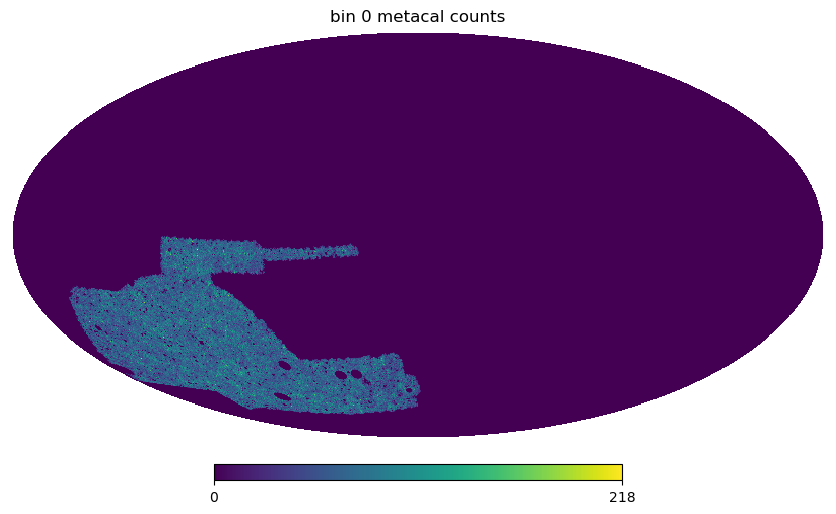

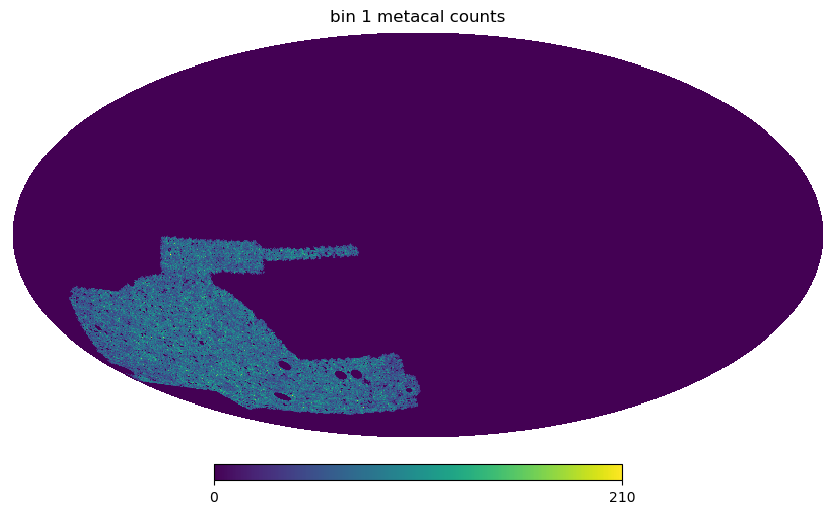

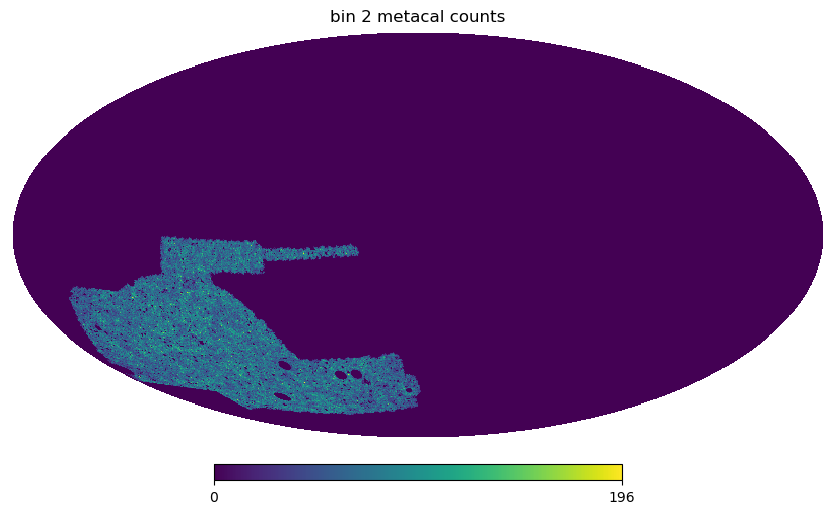

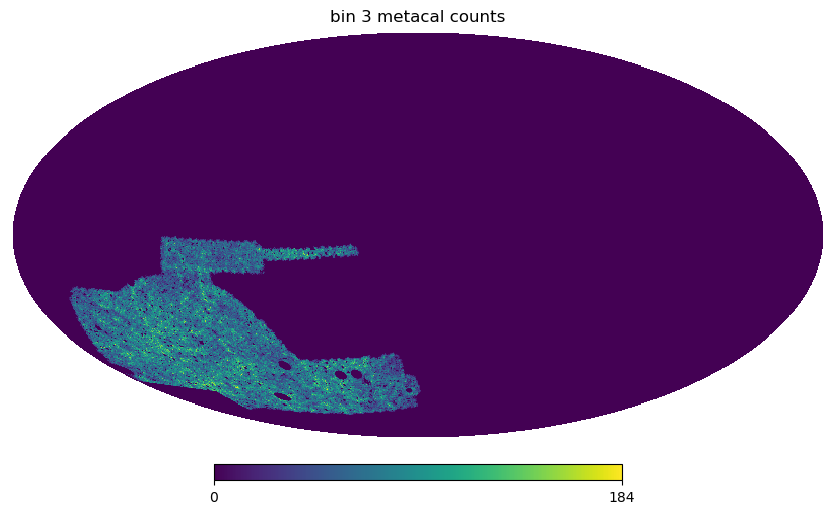

In [4]:
for i in range(n_z):
    hp.mollview(des_count_map[:,i], title=f"bin {i} metacal counts")

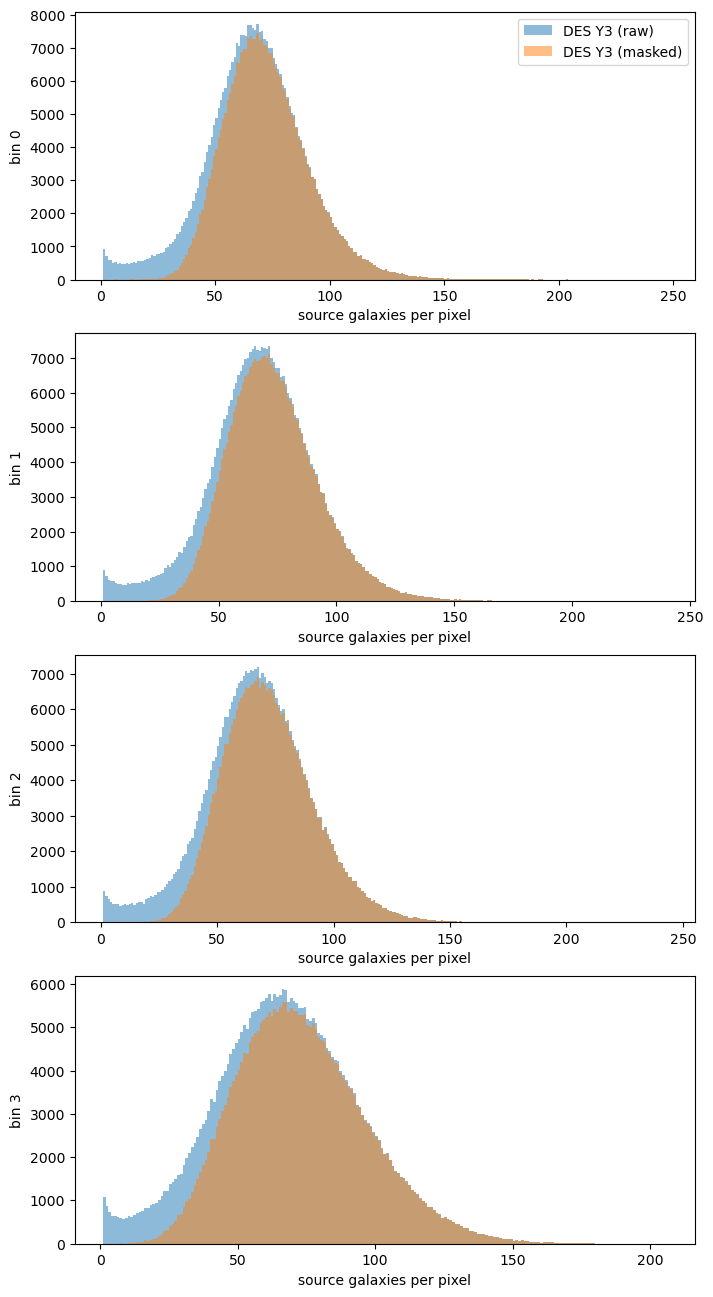

In [5]:
nrows = n_z

fig, ax = plt.subplots(figsize=(8, 4*nrows), nrows=nrows)

for i in range(nrows):
    # all pixels where there are galaxies
    full = des_count_map[:,i]
    full = full[full!=0]

    # footprint
    masked = des_count_fp[:,i]
        
    bins = np.arange(full.min(), full.max())
    
    ax[i].hist(full, bins=bins, label="DES Y3 (raw)", alpha=0.5)
    ax[i].hist(masked, bins=bins, label="DES Y3 (masked)", alpha=0.5)

    ax[i].set(xlabel="source galaxies per pixel", ylabel=f"bin {i}")

ax[0].legend()